# EuroSat Image Classification using Vision Transformer (ViT)


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,3,7"
import numpy as np 
import torch
import torchvision.transforms as transforms
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import wandb
from torch.utils.data import DataLoader
import json
from torchvision.models import vit_l_32,ViT_L_32_Weights
from torchvision.models import vit_b_32, vit_l_32, ViT_B_32_Weights, ViT_L_32_Weights

from train_utils import get_predictions,compute_val_loss,EarlyStopping,train_model
from eval_utils import remove_wandb_hooks,evaluate_test_set,precision_recall_analysis
from EuroSAT import EurosatDataset,visualize_fused_data

## Login to Wandb to log experiment

In [2]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'EuroSat_ViT_Classifier.ipynb'
wandb.login()

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find EuroSat_ViT_Classifier.ipynb.
wandb: Currently logged in as: wuwanxing3574 (wuwanxing3574-institut-polytechnique-de-paris) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data
The [EuroSat Dataset]...

In [3]:
data_path = "/data1/wwx/EuroSat_classification/EuroSAT_fused"
metadata_path = "/data1/wwx/EuroSat_classification/dataset/split_info"

In [4]:
# Load the labels from the new metadata_path
with open(os.path.join(metadata_path, "label_map.json"), "r") as f:
    label_to_index = json.load(f)

In [5]:
index_to_label = {v: k for k, v in label_to_index.items()}
print(index_to_label)

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


## Data Transformations

In [6]:
# Check the transformations used in the pre-trained model
weights = ViT_L_32_Weights.DEFAULT
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [7]:
# # Define a sequence of transformations to be applied to images
# transformToTensor = transforms.Compose([
#     transforms.Resize((256,)),
#     transforms.CenterCrop((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# added by wky
# Transform now only includes normalization
# First 3 values are RGB channels, the last 3 are NDVI, NDWI, NDBI channels
# For indices in the range -1 to 1, using mean=0.5 and std=0.5 is a reasonable starting point
transformToTensor = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406, 0.5, 0.5, 0.5], 
        std=[0.229, 0.224, 0.225, 0.5, 0.5, 0.5]
    )
])

In [8]:
# Create dataset instances
# Instantiate the EurosatDataset class using the new csv_path argument.
train_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'train.csv'),
    transform=transformToTensor,
    data_path=data_path
)

valid_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'valid.csv'),
    transform=transformToTensor,
    data_path=data_path
)

test_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'test.csv'),
    transform=transformToTensor,
    data_path=data_path
)

# Define batch sizes for training and validation data.
train_batch = 512
val_batch = 512

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=val_batch, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

/data1/wwx/EuroSat_classification/eurosat_deeplearning/eurosat_dl_fusion/EuroSAT.py:285: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应主标题
/data1/wwx/EuroSat_classification/eurosat_deeplearning/eurosat_dl_fusion/EuroSAT.py:285: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应主标题
/data1/wwx/EuroSat_classification/eurosat_deeplearning/eurosat_dl_fusion/EuroSAT.py:285: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应主标题
/data1/wwx/EuroSat_classification/eurosat_deeplearning/eurosat_dl_fusion/EuroSAT.py:285: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应主标题
/data1/wwx/EuroSat_classification/eurosat_deeplearning/euros

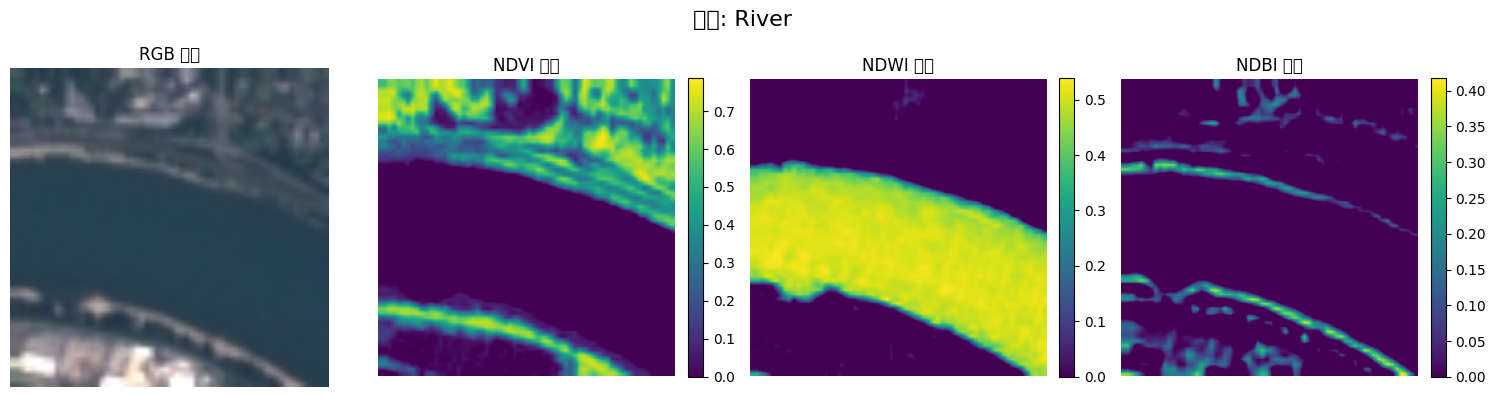

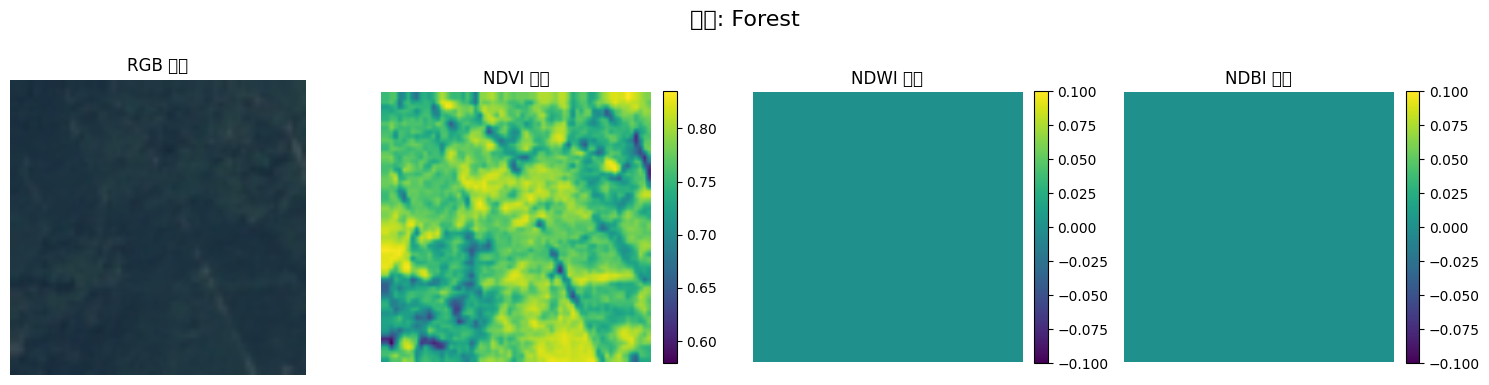

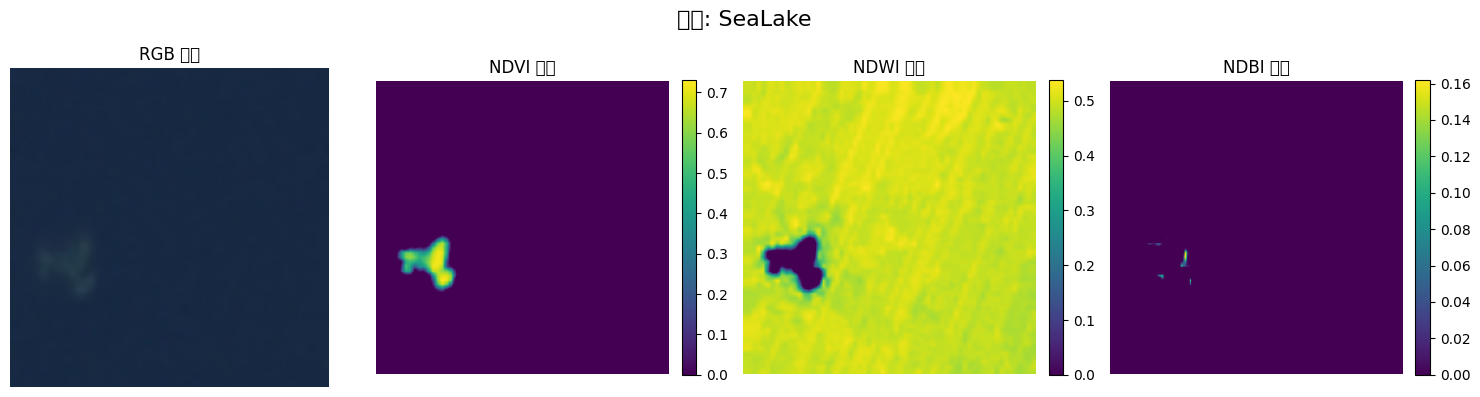

In [9]:
visualize_fused_data(train_loader, index_to_label)

In [10]:
dataset_managers = {
    'valid': valid_loader,
    'train': train_loader,
    'test': test_loader
}

print(f"Train set batches: {len(train_loader)}")
print(f"Validation set batches: {len(valid_loader)}")
print(f"Test set examples: {len(test_dataset)}")

Train set batches: 37
Validation set batches: 8
Test set examples: 4050


## Labels distribution

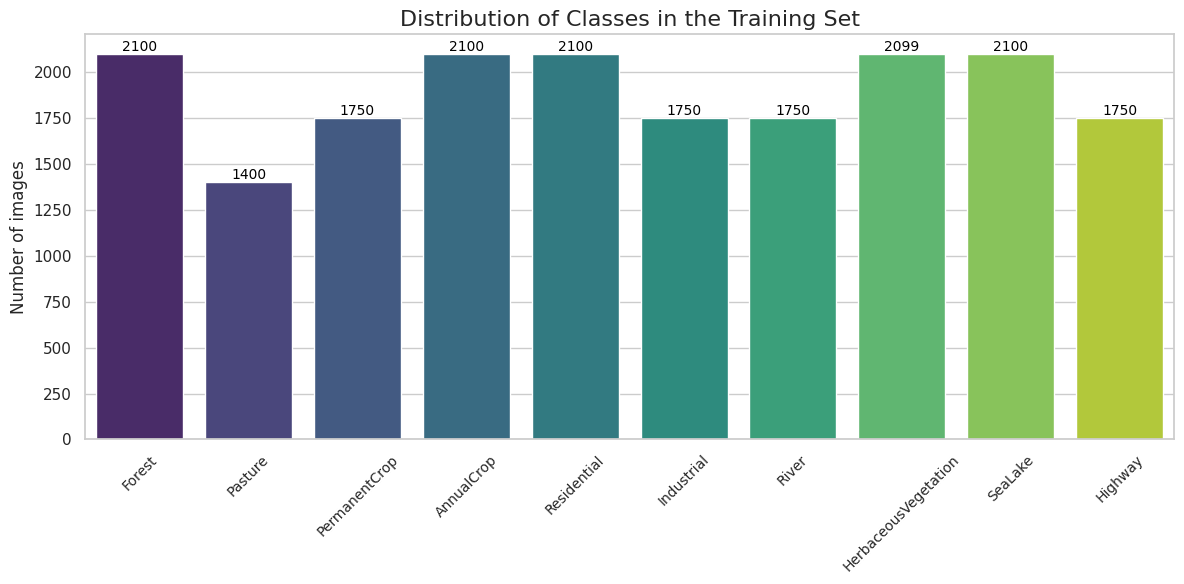

In [11]:
# Make sure to use the .data attribute from your updated EurosatDataset class
labels = train_dataset.data['Label'].values

# Convert numerical labels to string names
label_names = [index_to_label[label] for label in labels]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.countplot(x=label_names, hue=label_names, palette="viridis", legend=False)

plt.ylabel('Number of images', fontsize=12)
plt.title('Distribution of Classes in the Training Set', fontsize=16)
plt.xticks(rotation=45, fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Model

In [12]:
# Use un-pretrained model
model = vit_l_32()

# Replace the model head with the number of classes
num_classes = 10
model.heads.head = nn.Linear(1024, num_classes) 
original_conv = model.conv_proj
model.conv_proj = nn.Conv2d(
    in_channels=6, 
    out_channels=original_conv.out_channels,  # keep output channels unchanged (768)
    kernel_size=original_conv.kernel_size,   # keep kernel size unchanged
    stride=original_conv.stride             # keep stride unchanged
)

# also replace the final classification head
num_classes = 10
model = model.cuda() 
# model.to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Using 3 GPUs


# Training model from Scratch

In [13]:
# added by wky
project_name = "EuroSAT"
model_name = "ViT32-Scratch"
models_path = "./models/" # keep relative path

In [14]:
epochs = 20
lr = 0.0001
patience = 10

run = wandb.init(
    project=project_name,
    name=model_name,
    notes="ViT32 from scratch",
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })

loss_i, loss_val_i = train_model(model=model, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, 
                                 model_name=model_name)

Starting training with early stopping patience of 10
Each epoch has 37 steps.

Epoch: 1...
Step: 21/37 Loss: 2.4349395751953127
Validation Loss: 1.1698 Accuracy: 0.5643
Best model saved.
Epoch duration: 66.35s

Epoch: 2...
Step: 21/37 Loss: 1.1296891003847123
Validation Loss: 0.8556 Accuracy: 0.6937
Best model saved.
Epoch duration: 65.09s

Epoch: 3...
Step: 21/37 Loss: 0.8498955249786377
Validation Loss: 0.6342 Accuracy: 0.7786
Best model saved.
Epoch duration: 64.53s

Epoch: 4...
Step: 21/37 Loss: 0.6493309944868088
Validation Loss: 0.5495 Accuracy: 0.8013
Best model saved.
Epoch duration: 65.09s

Epoch: 5...
Step: 21/37 Loss: 0.5199895605444909
Validation Loss: 0.4953 Accuracy: 0.8262
Best model saved.
Epoch duration: 64.35s

Epoch: 6...
Step: 21/37 Loss: 0.4613016709685326
Validation Loss: 0.3844 Accuracy: 0.8660
Best model saved.
Epoch duration: 64.81s

Epoch: 7...
Step: 21/37 Loss: 0.40241479575634004
Validation Loss: 0.3958 Accuracy: 0.8618
Epoch duration: 61.39s

Epoch: 8...
St

## Save model

In [15]:
os.makedirs(models_path, exist_ok=True)
model_save_path = os.path.join(models_path, model_name + ".pth")
print(f"Saving model to: {model_save_path}")
torch.save(obj=model.state_dict(), f=model_save_path)

Saving model to: ./models/ViT32-Scratch.pth


In [16]:
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

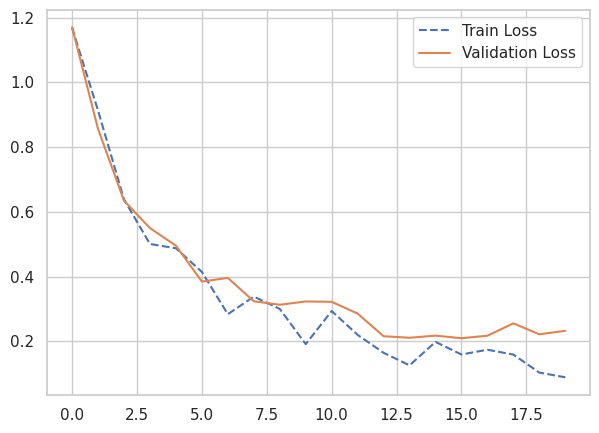

In [17]:
plt.figure(figsize=(7,5))
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

## (The following code blocks remain unchanged, continuing evaluation and further training)...

# Evaluate model

In [18]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [19]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model.load_state_dict(torch.load(f = model_save_path))

Loading model ./models/ViT32-Scratch.pth


<All keys matched successfully>

In [20]:
DEVICE = torch.device('cuda') 
evaluate_test_set(model, test_loader, DEVICE , index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.887     0.940     0.913       450
              Forest      0.989     0.973     0.981       450
HerbaceousVegetation      0.968     0.929     0.948       450
             Highway      0.841     0.832     0.836       375
          Industrial      0.928     0.933     0.931       375
             Pasture      0.925     0.860     0.891       300
       PermanentCrop      0.852     0.872     0.862       375
         Residential      0.887     0.956     0.920       450
               River      0.972     0.917     0.944       375
             SeaLake      0.996     0.991     0.993       450

            accuracy                          0.925      4050
           macro avg      0.924     0.920     0.922      4050
        weighted avg      0.926     0.925     0.925      4050



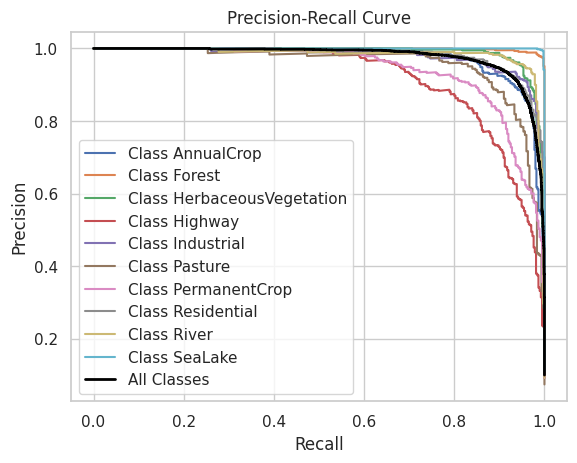

In [21]:
precision_recall_analysis(model, test_loader,DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [22]:
wandb.finish()

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▅▅▆▇▇▇▇▇▇▇████████
val_loss,█▆▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,19
step,723
train_loss,0.0847
val_accuracy,0.93039
val_loss,0.23236


## Load the precision/recall curve and plot it

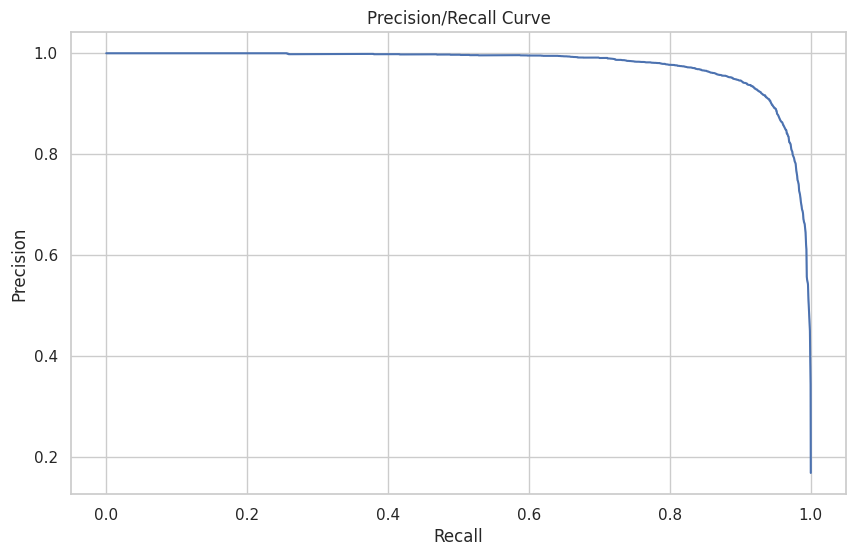

In [23]:
filename = f"{model_name}_precision_recall_values.json"
file_path = os.path.join(models_path, filename)

with open(file_path, 'r') as file:
    precision_recall_data = json.load(file)
    
all_classes_data = precision_recall_data['All Classes']

# Extract precision and recall values
precisions = all_classes_data.get('precision', [])
recalls = all_classes_data.get('recall', [])

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls
})

# Plotting the precision/recall curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Recall', y='Precision')
plt.title('Precision/Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

## Clean-up

In [24]:
import gc

del model
torch.cuda.empty_cache()
gc.collect()


446

# Now train the model with pre-trained weights

In [25]:
# Replace the model head with the number of classes
num_classes = 10

model2 = vit_l_32(weights=ViT_L_32_Weights.IMAGENET1K_V1)
model2.heads.head = nn.Linear(1024, num_classes) 
original_conv = model2.conv_proj
model2.conv_proj = nn.Conv2d(
    in_channels=6, 
    out_channels=original_conv.out_channels,  # keep output channels unchanged (768)
    kernel_size=original_conv.kernel_size,   # keep kernel size unchanged
    stride=original_conv.stride             # keep stride unchanged
)
model2 = model2.cuda()
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU")
    model2 = nn.DataParallel(model2)

使用 3 个GPU


## Train with pre-trained weights

In [26]:
model_name = "ViT32-Pretrained"
project_name = "EuroSAT"
models_path = "./models/" # keep relative path

In [ ]:
epochs = 10
lr = 0.0001
patience = 10

run = wandb.init(
    # Set the project where this run will be logged
    project=project_name,
    name=model_name,
    notes="ViT32 pre-trained on ImageNet",
    # Track hyperparameters and run metadata
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })


loss_i, loss_val_i = train_model(model=model2, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, 
                                 model_name=model_name)

Starting training with early stopping patience of 10
Each epoch has 37 steps.

Epoch: 1...


Step: 21/37 Loss: 1.1787441462278365
Validation Loss: 0.3789 Accuracy: 0.8721
Best model saved.
Epoch duration: 68.69s

Epoch: 2...
Step: 21/37 Loss: 0.3515423096716404
Validation Loss: 0.2361 Accuracy: 0.9242
Best model saved.
Epoch duration: 68.58s

Epoch: 3...
Step: 21/37 Loss: 0.19134349822998048
Validation Loss: 0.2352 Accuracy: 0.9232
Epoch duration: 68.51s

Epoch: 4...


## Save model

In [ ]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: ./models/ViT32-Pretrained.pth


In [ ]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as archivo:
    archivo.write(f"loss_i: {loss_i}\n")
    archivo.write(f"loss_val_i: {loss_val_i}\n")

In [ ]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

In [ ]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [ ]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model2.load_state_dict(torch.load(f = model_save_path))

In [ ]:
evaluate_test_set(model2, test_loader, DEVICE, index_to_label=index_to_label)

In [ ]:
precision_recall_analysis(model2, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [ ]:
wandb.finish()

In [ ]:
del model2
torch.cuda.empty_cache()
gc.collect()